# Rainfall Prediction Classifier in Australia

## Project Overview
This project develops an end-to-end Machine Learning pipeline to predict daily rainfall events in the Melbourne metropolitan area using historical Bureau of Meteorology weather observations.

### Objectives:
- Address data leakage by appropriately restructuring features and predicting the current day's rain based on historical metrics.
- Build a modular preprocessing pipeline using `scikit-learn` (`ColumnTransformer`, `StandardScaler`, `OneHotEncoder`).
- Optimize hyperparameter search using `GridSearchCV` with Stratified K-Fold cross-validation.
- Compare ensemble learning (**Random Forest Classifier**) against linear baseline (**Logistic Regression**) with class-imbalance adjustments.

## Installing Libraries

The required libraries can be installed in the active Jupyter kernel with:

```python
%pip install pandas numpy matplotlib seaborn scikit-learn
```

The `scikit-learn` package is used in the code through imports from the `sklearn` module.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1. Data Ingestion & Preprocessing

In [2]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
df = pd.read_csv(url)

# Drop missing values and filter for Melbourne metropolitan regional clusters
df = df.dropna()
df = df[df.Location.isin(['Melbourne', 'MelbourneAirport', 'Watsonia'])].copy()

# Address data leakage: predict today's rain given yesterday's full metrics
df = df.rename(columns={'RainToday': 'RainYesterday', 'RainTomorrow': 'RainToday'})

print(f"Cleaned dataset shape: {df.shape}")
df.head()

Cleaned dataset shape: (7557, 23)


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainYesterday,RainToday
64191,2009-01-01,MelbourneAirport,11.2,19.9,0.0,5.6,8.8,SW,69.0,W,...,55.0,37.0,1005.1,1006.4,7.0,7.0,15.9,18.1,No,Yes
64192,2009-01-02,MelbourneAirport,7.8,17.8,1.2,7.2,12.9,SSE,56.0,SW,...,50.0,43.0,1018.0,1019.3,6.0,7.0,12.5,15.8,Yes,No
64193,2009-01-03,MelbourneAirport,6.3,21.1,0.0,6.2,10.5,SSE,31.0,E,...,51.0,35.0,1020.8,1017.6,1.0,7.0,13.4,19.6,No,No
64194,2009-01-04,MelbourneAirport,8.1,29.2,0.0,6.4,12.5,SSE,35.0,NE,...,67.0,23.0,1016.2,1012.8,5.0,4.0,16.0,28.2,No,No
64195,2009-01-05,MelbourneAirport,9.7,29.0,0.0,7.4,12.3,SE,33.0,SW,...,51.0,31.0,1011.9,1010.3,6.0,2.0,19.4,27.1,No,No


## 2. Feature Engineering & Dataset Splitting

In [3]:
# Map dates to Australian seasonal calendar
def date_to_season(date):
    month = date.month
    if month in (12, 1, 2):
        return 'Summer'
    elif month in (3, 4, 5):
        return 'Autumn'
    elif month in (6, 7, 8):
        return 'Winter'
    else:
        return 'Spring'

df['Date'] = pd.to_datetime(df['Date'])
df['Season'] = df['Date'].apply(date_to_season)
df = df.drop(columns=['Date'])

# Target and feature separation
X = df.drop(columns=['RainToday'])
y = df['RainToday']

# Stratified train-test split (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Class distribution in target:")
print(y.value_counts(normalize=True))

Class distribution in target:
RainToday
No     0.763001
Yes    0.236999
Name: proportion, dtype: float64


## 3. Pipeline Construction & Preprocessing Transformers

In [4]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

C:\Users\chubo\AppData\Local\Temp\ipykernel_21188\1344555898.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


## 4. Model Training: Random Forest Classifier with Grid Search CV

In [5]:
rf_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_rf = GridSearchCV(pipeline, rf_param_grid, cv=cv, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best Cross-Validation Score: {grid_search_rf.best_score_:.4f}")
print(f"Test Set Accuracy: {grid_search_rf.score(X_test, y_test):.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best Cross-Validation Score: 0.8524
Test Set Accuracy: 0.8446


### Random Forest Evaluation

Random Forest Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.95      0.90      1154
         Yes       0.75      0.51      0.61       358

    accuracy                           0.84      1512
   macro avg       0.81      0.73      0.76      1512
weighted avg       0.84      0.84      0.83      1512



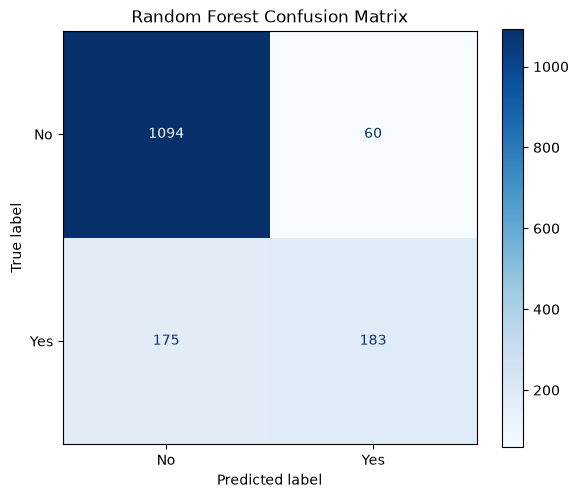

In [6]:
y_pred_rf = grid_search_rf.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues', ax=ax)
ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

### Feature Importance Analysis

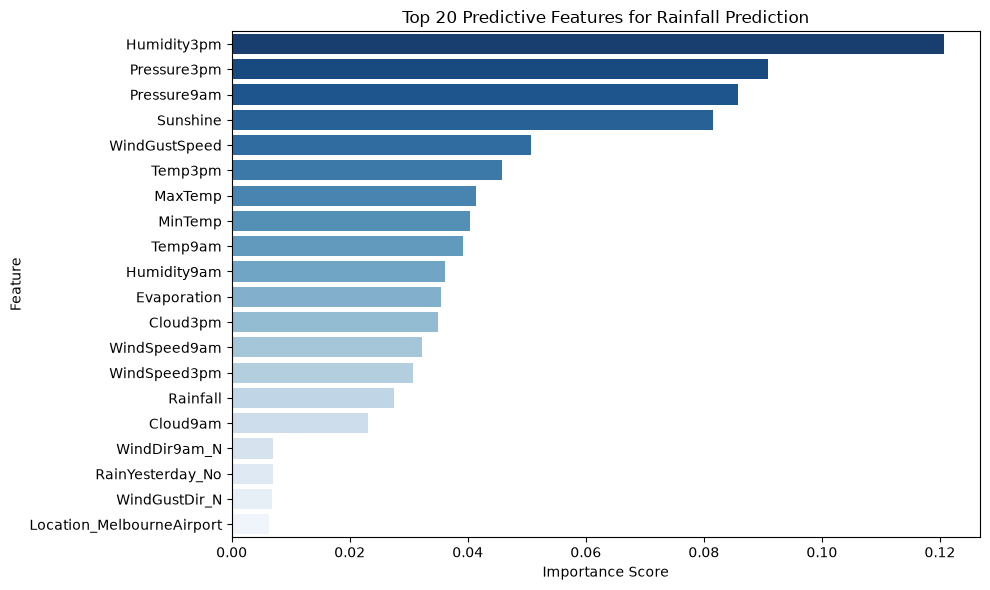

In [7]:
# Extract one-hot encoded and numerical feature names
cat_encoder = grid_search_rf.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + encoded_cat_names

importances = grid_search_rf.best_estimator_['classifier'].feature_importances_
importance_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
top_20_features = importance_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_20_features, x='Importance', y='Feature', palette='Blues_r', hue='Feature', legend=False)
plt.title('Top 20 Predictive Features for Rainfall Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 5. Model Comparison: Logistic Regression

In [8]:
# Update pipeline with Logistic Regression
pipeline.set_params(classifier=LogisticRegression(random_state=42))

lr_param_grid = {
    'classifier__solver': ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight': [None, 'balanced']
}

grid_search_lr = GridSearchCV(pipeline, lr_param_grid, cv=cv, scoring='recall_macro', verbose=1, n_jobs=-1)
grid_search_lr.fit(X_train, y_train)

print(f"Best Parameters (Logistic Regression): {grid_search_lr.best_params_}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best Parameters (Logistic Regression): {'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}


c:\Users\chubo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


### Logistic Regression Evaluation

Logistic Regression Classification Report:
              precision    recall  f1-score   support

          No       0.91      0.78      0.84      1154
         Yes       0.52      0.74      0.61       358

    accuracy                           0.77      1512
   macro avg       0.71      0.76      0.72      1512
weighted avg       0.81      0.77      0.79      1512



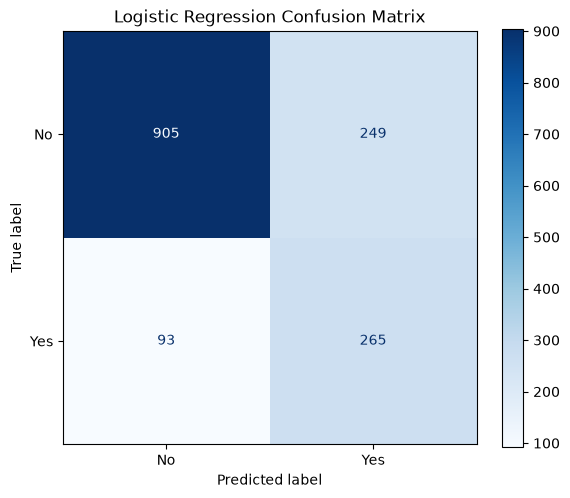

In [9]:
y_pred_lr = grid_search_lr.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap='Blues', ax=ax)
ax.set_title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

## 6. Key Conclusions & Findings

- **Feature Dominance:** Consistent with meteorological reality, atmospheric humidity (`Humidity3pm`) and barometric pressure trends are the highest predictors of rainfall events.
- **Handling Class Imbalance:** In weather forecasting, a False Negative (missing rain) is significantly more disruptive than a False Positive. While **Random Forest** achieved higher raw accuracy (~84%), it produced an unsatisfactory True Positive Rate (~51%).
- **Model Selection Verdict:** When configured with balanced class weighting, **Logistic Regression** optimizes the recall of rainfall events, achieving a higher True Positive Rate with only a minimal trade-off in overall accuracy.